In [1]:
import sys
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import importlib
import json
from pathlib import Path
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm
import logging

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
)

logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing")
DATA_DIR = PROJECT_DIR / "data"
CHKPT_DIR = PROJECT_DIR / "checkpoints"
CHKPT_COPY_DIR = PROJECT_DIR / "checkpoints copy"
RESULT_DIR = PROJECT_DIR / "testing_results"

sys.path.append(str(PROJECT_DIR))

import models.tf_to_tg as tf_to_tg_module
import models.tf_to_dna as tf_to_dna_module
import datasets.tftg_dataset as tftg_dataset_module
import scripts.build_tf_to_tg_train_data as tf_tg_data_builder
import utils
import warnings

warnings.filterwarnings(
    "ignore",
    message="You are using `torch.load` with `weights_only=False`.*",
    category=FutureWarning,
)

tf_tg_input_cache_dir = DATA_DIR / "tf_tg_training_cache"

all_evaluation_plot_dir = PROJECT_DIR / "plots" / "model_vs_test_set_evaluation_figs"
all_evaluation_plot_dir.mkdir(exist_ok=True)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

## Helper Functions

In [2]:
def find_latest_checkpoint(cell_type, sample_name, training_number=None) -> Path:
    sample_chkpt_dir = CHKPT_DIR / cell_type / sample_name
    
    if not sample_chkpt_dir.exists():
        logging.warning(f"No checkpoints found for {cell_type} {sample_name} in {sample_chkpt_dir}")
        return None
    
    if training_number is not None:
        slurm_job_dirs = [d for d in sample_chkpt_dir.iterdir() if d.is_dir() and d.name.startswith(f"tf_tg_train_{sample_name}_{training_number}")]
    else:
        slurm_job_dirs = [d for d in sample_chkpt_dir.iterdir() if d.is_dir() and d.name.startswith(f"tf_tg_train_{sample_name}_")]
    
    if not slurm_job_dirs:
        logging.warning(f"No checkpoint directories found for {cell_type} {sample_name} in {sample_chkpt_dir}")
        return None
    
    latest_chkpt_dir = max(slurm_job_dirs, key=lambda d: int(d.name.split("_")[-1]))
    slurm_job_id = latest_chkpt_dir.name.split("_")[-1]
    
    chkpt_files = list(latest_chkpt_dir.glob("epoch=*-val_auroc=*-val_loss=*.ckpt"))
    if not chkpt_files:
        logging.warning(f"No checkpoint files found for {sample_name} in {latest_chkpt_dir}")
        return None
    
    latest_chkpt_file = max(chkpt_files, key=lambda f: int(f.stem.split("-")[0].split("=")[1]))
    epoch = latest_chkpt_file.stem.split("-")[0].split("=")[1]
    
    logging.info(f"Latest checkpoint for {cell_type} {sample_name}: Job {slurm_job_id} Epoch {epoch}")
    return latest_chkpt_file

def read_sample_input_data(sample_input_data_dir: Path):
    # Load in the ATAC pseudobulk and filter to only include peaks on the test chromosomes
    atac_pseudobulk = pd.read_parquet(sample_input_data_dir / "RE_pseudobulk.parquet")


    # Load in the RNA pseudobulk
    rna_pseudobulk = pd.read_parquet(sample_input_data_dir / "TG_pseudobulk.parquet")
    rna_pseudobulk.index = rna_pseudobulk.index.str.upper()

    # Load in the peak to gene distance
    peak_to_gene_distance = pd.read_parquet(sample_input_data_dir / "peak_to_gene_dist.parquet")
    peak_to_gene = peak_to_gene_distance.copy()
    peak_to_gene["target_id_norm"] = peak_to_gene["target_id"].str.upper()
    
    return atac_pseudobulk, rna_pseudobulk, peak_to_gene

def load_tf_tg_regulation_model(
    tf_dna_model_path: Path, 
    tf_tg_model_path: Path,
    tf_embeddings_tensor: torch.Tensor,
    tf_mask_tensor: torch.Tensor
    ) -> tf_to_tg_module.TFTGRegulationModel:
    
    # 1) Recreate the base TF→DNA model with the same hyperparameters
    base_model = tf_to_dna_module.TFPeakBindingModel(
        tf_embedding_dim=128,
        hidden_dim=128,
        dropout=0.3,
        num_layers=4,
        num_heads=4,
        dim_head=32,
    )

    # 2) Wrap in Lightning module and load checkpoint
    lit_model = tf_to_dna_module.LitTFPeakBindingModel.load_from_checkpoint(
        checkpoint_path=tf_dna_model_path,
        model=base_model,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        lr=1e-4,
        weight_decay=1e-4,
        pos_weight=None,
    )

    # 4) Get the trained TF-DNA model and freeze it
    trained_tf_peak_model = lit_model.model
    trained_tf_peak_model.eval()
    for p in trained_tf_peak_model.parameters():
        p.requires_grad = False

    # 5) Create the TF-TG model object using the trained TF-DNA model, and load the trained model checkpoint
    tf_tg_model = tf_to_tg_module.LitTFTGRegulationModel.load_from_checkpoint(
        checkpoint_path=tf_tg_model_path,
        model=tf_to_tg_module.TFTGRegulationModel(
            pretrained_tf_peak_model=trained_tf_peak_model,
            d_model=128,
            tf_peak_chunk_size=256,
        ),
        lr=1e-4,
        weight_decay=1e-4,
        pos_weight=None,
    )
    
    return tf_tg_model

def create_ground_truth_comparison_df(score_df, ground_truth_lookup, ground_truth_name):
    gt_tfs, gt_tgs, gt_pairs_set = ground_truth_lookup

    src = score_df["Source"].str.upper()
    tgt = score_df["Target"].str.upper()
    
    # Subset the score_df to only include edges where both TF and TG are in the ground truth test set
    mask = src.isin(gt_tfs) & tgt.isin(gt_tgs)
    df = score_df.loc[mask].copy()
    
    # Build the ground truth labels for the subsetted DataFrame
    df["Source"] = src.loc[mask].values
    df["Target"] = tgt.loc[mask].values

    key = df["Source"] + "\t" + df["Target"]
    df["_in_gt"] = key.isin(gt_pairs_set).astype("int8")
    df["ground_truth_name"] = ground_truth_name

    return df

def create_tf_tg_index_to_name_mappings(metadata):
    tf_idx_to_name = {idx: name for name, idx in metadata["tf_name_to_idx"].items()}
    tg_idx_to_name = {idx: name for name, idx in metadata["tg_id_to_idx"].items()}
    return tf_idx_to_name, tg_idx_to_name

def create_tf_tg_label_df(tftg_inputs_test):
    # Create the TF-TG label DataFrame
    tftg_inputs_test.keys()
    test_tf_input = tftg_inputs_test["tf_name"]
    test_tg_input = tftg_inputs_test["tg_name"]
    test_labels = tftg_inputs_test["label"]

    # create TF-TG label DataFrame
    tf_tg_label_df = pd.DataFrame({
        "Source": test_tf_input,
        "Target": test_tg_input,
        "Label": test_labels,
    })

    tf_tg_label_df = tf_tg_label_df.drop_duplicates(["Source", "Target"])

    gt_df: pd.DataFrame = tf_tg_label_df[tf_tg_label_df["Label"] == 1] 
    gt_tfs = set(gt_df["Source"].str.upper().unique()) 
    gt_targets = set(gt_df["Target"].str.upper().unique()) 
    gt_pairs = set(gt_df["Source"].str.upper() + "\t" + gt_df["Target"].str.upper())
    
    return tf_tg_label_df, gt_pairs, gt_tfs, gt_targets

def load_and_standardize_method(name: str, info: dict) -> pd.DataFrame:
    """
    Load a GRN CSV and rename tf_col/target_col/score_col -> Source/Target/Score.
    Extra columns are preserved.
    """
    if info["path"].suffix == ".tsv":
        sep = "\t"
    elif info["path"].suffix == ".csv":
        sep = ","
    
    df = pd.read_csv(info["path"], sep=sep, header=0, index_col=None)

    tf_col     = info["tf_col"]
    target_col = info["target_col"]
    score_col  = info["score_col"]

    rename_map = {
        tf_col: "Source",
        target_col: "Target",
        score_col: "Score",
    }

    missing = [c for c in rename_map if c not in df.columns]
    if missing:
        raise ValueError(f"[{name}] Missing expected columns: {missing}. Got: {list(df.columns)}")

    df = df.rename(columns=rename_map)

    df = df[["Source", "Target", "Score"]]
    df["Source"] = df["Source"].astype(str).str.upper()
    df["Target"] = df["Target"].astype(str).str.upper()

    return df

def compute_metrics(name: str, df: pd.DataFrame, gt_pairs: set, score_threshold: float):            
    labels = [1 if pair in gt_pairs else 0 for pair in df["Source"] + "\t" + df["Target"]]
    scores = df["Score"].tolist()
    
    labels = np.asarray(labels).astype(int).ravel()
    scores = np.asarray(scores).astype(float).ravel()

    preds = (scores >= score_threshold).astype(int)

    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)

    if len(np.unique(labels)) < 2:
        auroc = np.nan
        auprc = np.nan
        rand_auroc = np.nan
        rand_auprc = np.nan
    else:
        auroc = roc_auc_score(labels, scores)
        auprc = average_precision_score(labels, scores)

        rng = np.random.default_rng(42)
        rand_scores = rng.permutation(scores)

        rand_auroc = roc_auc_score(labels, rand_scores)
        rand_auprc = average_precision_score(labels, rand_scores)

    return pd.DataFrame([{
        "method_name": name,
        "auroc": auroc,
        "auprc": auprc,
        "rand_auroc": rand_auroc,
        "rand_auprc": rand_auprc,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "n_edges": len(labels),
        "n_pos": int(labels.sum()),
        "n_neg": int((labels == 0).sum()),
        "score_threshold": score_threshold,
    }])
    
def build_full_universe_from_gt(method_df, gt_edges, use_abs_scores=True, missing_score=0.0):
    universe_tfs = gt_edges["Source"].dropna().unique()
    universe_tgs = gt_edges["Target"].dropna().unique()

    gt_pairs = set(zip(gt_edges["Source"], gt_edges["Target"]))

    full_universe = (
        pd.MultiIndex
        .from_product([universe_tfs, universe_tgs], names=["Source", "Target"])
        .to_frame(index=False)
    )

    full_universe["_in_gt"] = [
        1 if pair in gt_pairs else 0
        for pair in zip(full_universe["Source"], full_universe["Target"])
    ]

    method_scores = method_df[["Source", "Target", "Score"]].copy()

    if use_abs_scores:
        method_scores["Score"] = method_scores["Score"].abs()

    # If method has duplicate Source-Target edges, keep strongest score
    method_scores = (
        method_scores
        .sort_values("Score", ascending=False)
        .drop_duplicates(["Source", "Target"], keep="first")
    )

    full_universe = full_universe.merge(
        method_scores,
        on=["Source", "Target"],
        how="left",
    )

    full_universe["Score"] = full_universe["Score"].fillna(missing_score)

    # print(f"Complete TF-target universe size: {len(full_universe):,}")
    # print(
    #     f"Positives in universe: {(full_universe['_in_gt'] == 1).sum():,}"
    #     f" | Negatives: {(full_universe['_in_gt'] == 0).sum():,}"
    # )

    return full_universe

def convert_labeled_dataframe_to_indices(true_interactions, false_interactions, tf_name_to_idx, tg_id_to_idx):
    rows = []
    for tf, tg in true_interactions:
        rows.append((tf, tg, 1))
    for tf, tg in false_interactions:
        rows.append((tf, tg, 0))

    df = pd.DataFrame(rows, columns=["tf_name", "tg_id", "label"])
    df["tf_idx"] = df["tf_name"].str.upper().map(tf_name_to_idx)
    df["tg_idx"] = df["tg_id"].str.upper().map(tg_id_to_idx)

    missing_mask = df["tf_idx"].isna() | df["tg_idx"].isna()
    if missing_mask.any():
        n_missing = missing_mask.sum()
        logging.info(f"Dropping {n_missing} interactions with missing TF or TG indices.")
        df = df.loc[~missing_mask].copy()

    df["tf_idx"] = df["tf_idx"].astype(np.int64)
    df["tg_idx"] = df["tg_idx"].astype(np.int64)
    df["label"] = df["label"].astype(np.float32)

    return df

def sample_auprc_10x_negatives(full_universe, random_state=42):
    positives = full_universe[full_universe["_in_gt"] == 1]
    negatives = full_universe[full_universe["_in_gt"] == 0]

    n_pos = len(positives)
    n_neg_sample = min(n_pos * 10, len(negatives))

    if n_pos == 0 or n_neg_sample == 0:
        return full_universe.iloc[0:0].copy()

    neg_sampled = negatives.sample(
        n=n_neg_sample,
        replace=False,
        random_state=random_state,
    )

    auprc_df = pd.concat([positives, neg_sampled], axis=0)

    # Optional: shuffle, not required for sklearn metrics
    auprc_df = auprc_df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)

    return auprc_df

## Load Checkpoints

In [3]:
mm10_tf_dna_path = CHKPT_DIR / "tf_dna_mm10_3671604" / "epoch=08-val_auroc=0.9177-val_loss=0.2783.ckpt"
hg38_tf_dna_path = CHKPT_DIR / "tf_dna_hg38_3683606" / "epoch=13-val_auroc=0.9566-val_loss=0.2042.ckpt"

tf_dna_model_checkpoints = {
    "mESC": mm10_tf_dna_path,
    "iPSC": hg38_tf_dna_path,
    "Macrophage": hg38_tf_dna_path,
    "K562": hg38_tf_dna_path
}

tf_tg_model_checkpoints = {
    "mESC": {
        "E7.5_rep1": CHKPT_DIR / "mESC" / "E7.5_rep1" / "tf_tg_train_E7.5_rep1_3675131" / "epoch_11_best_model.ckpt",
        "E7.5_rep2": find_latest_checkpoint("mESC", "E7.5_rep2"),
        "E8.5_rep1": find_latest_checkpoint("mESC", "E8.5_rep1", training_number="3691937"),
        "E8.5_rep2": find_latest_checkpoint("mESC", "E8.5_rep2"),
    },
    "iPSC": {
        "WT_D13_rep1": find_latest_checkpoint("iPSC", "WT_D13_rep1"),
    },
    "Macrophage": {
        "buffer_1": find_latest_checkpoint("Macrophage", "buffer_1", training_number="3685893"),
        "buffer_2": find_latest_checkpoint("Macrophage", "buffer_2"),
        "buffer_3": find_latest_checkpoint("Macrophage", "buffer_3"),
        "buffer_4": find_latest_checkpoint("Macrophage", "buffer_4"),
    },
    "K562": {
        "sample_1": find_latest_checkpoint("K562", "sample_1"),
    }
}


INFO - Latest checkpoint for mESC E7.5_rep2: Job 3696113 Epoch 76
INFO - Latest checkpoint for mESC E8.5_rep1: Job 3691937 Epoch 42
INFO - Latest checkpoint for mESC E8.5_rep2: Job 3696124 Epoch 67
INFO - Latest checkpoint for iPSC WT_D13_rep1: Job 3683642 Epoch 75
INFO - Latest checkpoint for Macrophage buffer_1: Job 3685893 Epoch 152
INFO - Latest checkpoint for Macrophage buffer_2: Job 3685903 Epoch 53
INFO - Latest checkpoint for Macrophage buffer_3: Job 3696133 Epoch 249
INFO - Latest checkpoint for Macrophage buffer_4: Job 3696147 Epoch 209
INFO - Latest checkpoint for K562 sample_1: Job 3692409 Epoch 63


In [27]:
def generate_dataloader(cell_type, sample_name, species):
    project_data_dir = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data")

    logging.info(f"Evaluating on {cell_type} {sample_name} ({species})")
    if species == "mm10":
        gene_ref_file = project_data_dir / "genome_data" / "genome_annotation" / "mm10" / "Mus_musculus.GRCm39.115.gtf.gz"
    elif species == "hg38":
        gene_ref_file = project_data_dir / "genome_data" / "genome_annotation" / "hg38" / "Homo_sapiens.GRCh38.113.gtf.gz"

    genome_fasta_path = project_data_dir / "genome_data" / "reference_genome" / f"{species}" / f"{species}.fa"
    chrom_sizes_path = project_data_dir / "genome_data" / "reference_genome" / f"{species}" / f"{species}.chrom.sizes"
    chrom_sizes_path = project_data_dir / "genome_data" / "reference_genome" / f"{species}" / f"{species}.chrom.sizes"

    if species == "mm10":
        train_chroms = [str(i) for i in range(1, 16)]
        val_chroms = [ str(i) for i in range(16, 18)]
        test_chroms = [str(i) for i in range(18, 20)]
    elif species == "hg38":
        train_chroms = [str(i) for i in range(1, 18)]
        val_chroms = [str(i) for i in range(18, 20)]
        test_chroms = [str(i) for i in range(20, 23)]

    sample_input_data_dir = PROJECT_DIR / "data" / "sample_input_data" / cell_type / sample_name

    atac_pseudobulk, rna_pseudobulk, peak_to_gene = read_sample_input_data(sample_input_data_dir)

    dataset_peaks = atac_pseudobulk.index.to_list()
    dataset_peaks = [peak for peak in dataset_peaks if peak.split(":", 1)[0].replace("chr", "") in test_chroms]

    # Create a peak to index map for the peaks on the test chromosomes
    atac_peak_map = {peak: idx for idx, peak in enumerate(dataset_peaks)}

    common_cells = sorted(set(rna_pseudobulk.columns) & set(atac_pseudobulk.columns))

    # Load the merged ground truth
    cell_type_cache_dir = DATA_DIR / f"{cell_type}_cache"
    merged_ground_truth_df = pd.read_parquet(cell_type_cache_dir / f"{cell_type}_merged_ground_truth.parquet")

    # Load the TF and TG name to index mappings from the training cache metadata
    with open(cell_type_cache_dir / "tf_tg_training_cache" / sample_name / "metadata.json", "r") as f:
        metadata = json.load(f)
        
    tf_name_to_idx = metadata["tf_name_to_idx"]
    tg_id_to_idx = metadata["tg_id_to_idx"]

    pct_true_edges = 1.0
    true_false_ratio = 1.0

    # Create labeled TF-TG datasets for train/val/test splits
    # (samples true and false edges according to pct_true_edges and true_false_ratio)
    tf_tg_labeled_df = tf_tg_data_builder._create_labeled_df(
        merged_ground_truth_df,
        pct_true_edges,
        true_false_ratio,
        seed=123,
        tf_name_to_idx=tf_name_to_idx,
        tg_id_to_idx=tg_id_to_idx,
    )

    # Create the centered one-hot encoded ATAC peak array for the test set
    atac_peak_array = utils.create_centered_peak_onehot_array(
        peak_ids=dataset_peaks,
        genome_fasta=genome_fasta_path,
        chrom_sizes=utils.load_chrom_sizes(chrom_sizes_path),
        peak_id_to_idx=atac_peak_map,
        flank_size=128,
        dtype=np.uint8,
        pad_out_of_bounds=True,
        num_workers=10,
        show_progress=False,
        chunk_size=10000,
    )
    atac_peak_tensor = torch.as_tensor(atac_peak_array, dtype=torch.uint8).float()

    # Prepare the lookup tables needed to build the TF-TG input dataset for the test set
    tg_to_peak_info, cell_to_idx, atac_mat, rna_mat, gene_to_rna_idx = tf_tg_data_builder.prepare_tftg_lookup_tables(
        peak_to_gene=peak_to_gene,
        atac_peak_map=atac_peak_map,
        atac_pseudobulk=atac_pseudobulk,
        rna_pseudobulk_norm=rna_pseudobulk,
        dataset_peaks=dataset_peaks,
        common_cells=common_cells,
        max_precompute_peaks=8,
    )

    # Build the compact TF-TG input dataset for the test set
    common_build_kwargs = dict(
        max_peaks_per_tg=8,
        max_cells_per_pair=16,
        tg_to_peak_info=tg_to_peak_info,
        cell_to_idx=cell_to_idx,
        atac_mat=atac_mat,
        rna_mat=rna_mat,
        gene_to_rna_idx=gene_to_rna_idx,
        common_cells=common_cells,
        tf_name_to_idx=tf_name_to_idx,
        tg_id_to_idx=tg_id_to_idx,
    )

    tftg_inputs = tf_tg_data_builder.build_tftg_inputs(
        tf_tg_labeled_df,
        seed=125,
        silence=True,
        **common_build_kwargs,
    )

    # Load the lookup tensors
    tf_embeddings_tensor = torch.load(
        cell_type_cache_dir / "tf_embeddings.pt",
        weights_only=True,
    )
    tf_mask_tensor = torch.load(
        cell_type_cache_dir / "tf_masks.pt",
        weights_only=True,
    )

    # Create the dataset for the test set using the loaded inputs and lookup tensors
    dataset = tftg_dataset_module.TFTGEdgeBagDataset(
        tftg_inputs,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        atac_peak_tensor=atac_peak_tensor
    )

    # Create the DataLoader for the test set
    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
        persistent_workers=False,
        collate_fn=tftg_dataset_module.collate_tftg_edge_bags,
    )
    
    return loader, tf_embeddings_tensor, tf_mask_tensor

## Create a DataLoader for the sample

In [28]:
species = "hg38"
cell_type = "Macrophage"
sample_name = "buffer_2"

tf_dna_model_chkpt = tf_dna_model_checkpoints[cell_type]

data_loader, tf_embeddings_tensor, tf_mask_tensor = generate_dataloader(cell_type, sample_name, species)

INFO - Evaluating on Macrophage buffer_2 (hg38)
INFO - Sampling 100.00% of true edges.
INFO -   - Sampled 146,381 of 146,381 true edges


Generating sampled unobserved TF-item edges:   0%|                                                | 0/146381 […

## Load a trained TF-DNA binding model

In [29]:
# Generate the model predictions for the test set and create a DataFrame with TF names, TG names, and predicted scores
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Recreate the base TF→DNA model with the same hyperparameters
base_model = tf_to_dna_module.TFPeakBindingModel(
    tf_embedding_dim=128,
    hidden_dim=128,
    dropout=0.3,
    num_layers=4,
    num_heads=4,
    dim_head=32,
)

# 2) Wrap in Lightning module and load checkpoint
lit_model = tf_to_dna_module.LitTFPeakBindingModel.load_from_checkpoint(
    checkpoint_path=tf_dna_model_chkpt,
    model=base_model,
    tf_embeddings_tensor=tf_embeddings_tensor,
    tf_mask_tensor=tf_mask_tensor,
    lr=1e-4,
    weight_decay=1e-4,
    pos_weight=None,
)

# 4) Get the trained TF-DNA model and freeze it
trained_tf_peak_model = lit_model.model
trained_tf_peak_model.eval()
for p in trained_tf_peak_model.parameters():
    p.requires_grad = False

## TF-TG Binding Model Architecture

In [24]:
class TFTGRegulationModel(nn.Module):
    def __init__(
        self,
        pretrained_tf_peak_model,
        d_model,
        num_heads=4,
        dropout=0.1,
        tf_peak_chunk_size=256,
    ):
        super().__init__()

        self.tf_peak_model = pretrained_tf_peak_model
        self.tf_peak_chunk_size = tf_peak_chunk_size

        # Frozen TF-peak feature extractor
        for p in self.tf_peak_model.parameters():
            p.requires_grad = False

        self.peak_feature_proj = nn.Sequential(
            nn.Linear(2, d_model),  # binding, accessibility
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )

        self.tf_expr_proj = nn.Sequential(
            nn.Linear(1, d_model),
            nn.SiLU(),
            nn.Linear(d_model, d_model),
        )

        self.tg_expr_proj = nn.Sequential(
            nn.Linear(1, d_model),
            nn.SiLU(),
            nn.Linear(d_model, d_model),
        )

        self.gene_expr_query_proj = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.SiLU(),
            nn.Linear(d_model, d_model),
        )

        self.peak_attention = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.norm = nn.LayerNorm(d_model)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1),
        )

    @staticmethod
    def pool_cell_logits(
        cell_logits,
        cell_mask=None,
        mode="lse",
        temperature=1.0,
    ):
        """
        cell_logits: [E, C]
        cell_mask: [E, C], True for real cells, False for padded cells
        """

        if cell_mask is None:
            cell_mask = torch.ones_like(cell_logits, dtype=torch.bool)

        if mode == "mean":
            masked_logits = cell_logits.masked_fill(~cell_mask, 0.0)
            denom = cell_mask.sum(dim=1).clamp_min(1)
            return masked_logits.sum(dim=1) / denom

        elif mode == "max":
            masked_logits = cell_logits.masked_fill(~cell_mask, float("-inf"))
            return masked_logits.max(dim=1).values

        elif mode == "lse":
            masked_logits = cell_logits.masked_fill(~cell_mask, float("-inf"))
            n_cells = cell_mask.sum(dim=1).clamp_min(1)

            return temperature * (
                torch.logsumexp(masked_logits / temperature, dim=1)
                - torch.log(n_cells.float())
            )

        else:
            raise ValueError(f"Unknown pooling mode: {mode}")

    def forward(
        self,
        tf_embedding,
        tf_mask,
        peak_sequences,
        peak_accessibility,
        tf_expression,
        tg_expression,
        cell_mask,
        peak_mask,
        pooling_mode: str = "lse",
        pooling_temperature: float = 1.0,
    ):
        """
        Bag-level forward pass.

        This computes TF-DNA binding once per TF-TG edge and peak,
        then reuses those binding scores across sampled cells.

        Parameters
        ----------
        tf_embedding : [E T, D]
        tf_mask : [E, T]
        peak_sequences : [E, P, L, 4]
        peak_accessibility : [E, C, P]
        tf_expression : [E, C]
        tg_expression : [E, C]
        cell_mask : [E, C]
        peak_mask : [E, P]

        Returns
        -------
        edge_logits : [E]
        cell_logits : [E, C]
        """

        if not torch.is_floating_point(peak_sequences):
            peak_sequences = peak_sequences.float()

        E, C = cell_mask.shape
        _, P, L, nuc_dim = peak_sequences.shape
        EC = E * C

        # ------------------------------------------------------------
        # 1. Cell-invariant edge-level tensors
        # ------------------------------------------------------------
        # These are repeated across cells in your current dataloader.
        # Use only the first cell to avoid C-fold redundant TF-DNA inference.
        tf_embedding_edge = tf_embedding         # [E, T, D]
        tf_mask_edge = tf_mask                  # [E, T]
        peak_sequences_edge = peak_sequences    # [E, P, L, 4]
        peak_mask_edge = peak_mask            # [E, P]

        # ------------------------------------------------------------
        # 2a. Frozen TF-DNA binding model: [E, P]
        # ------------------------------------------------------------

        peak_seq_flat = peak_sequences_edge.reshape(E * P, L, nuc_dim)

        chunk_size = self.tf_peak_chunk_size
        if chunk_size is None or chunk_size <= 0:
            chunk_size = E * P

        binding_logits_chunks = []

        with torch.no_grad():
            self.tf_peak_model.eval()

            # Make sure the frozen TF-DNA model is on the same device.
            input_device = peak_sequences_edge.device

            for start in range(0, E * P, chunk_size):
                end = min(start + chunk_size, E * P)

                # Flat TF-peak indices: 0...(E*P - 1)
                flat_idx = torch.arange(start, end, device=input_device)

                # Convert flat TF-peak index back to edge index.
                # Example: if P=8, flat indices 0..7 use edge 0,
                # 8..15 use edge 1, etc.
                edge_idx = flat_idx // P

                # Gather only this chunk's TF embedding/mask.
                # Shape: [chunk, T, D]
                tf_embedding_chunk = tf_embedding_edge[edge_idx]
                tf_mask_chunk = tf_mask_edge[edge_idx]

                # Gather only this chunk's peak sequences.
                peak_seq_chunk = peak_seq_flat[start:end]

                logits_chunk = self.tf_peak_model(
                    tf_embedding=tf_embedding_chunk,
                    tf_mask=tf_mask_chunk,
                    peak_embedding=peak_seq_chunk,
                )

                binding_logits_chunks.append(logits_chunk)

        binding_logits = torch.cat(binding_logits_chunks, dim=0).reshape(E, P)
        
        # ------------------------------------------------------------
        # 2b. Mask and expand TF-peak binding scores across cells
        # ------------------------------------------------------------
        binding_score = torch.sigmoid(binding_logits)  # [E, P]
        
        binding_score = binding_score.masked_fill(~peak_mask_edge, 0.0)

        # Reuse TF-peak binding score across cells
        binding_score = binding_score[:, None, :].expand(E, C, P)  # [E, C, P]

        # ------------------------------------------------------------
        # 4. Cell-specific peak features
        # ------------------------------------------------------------
        peak_accessibility = peak_accessibility.masked_fill(
            ~peak_mask_edge[:, None, :],
            0.0,
        )
        
        peak_features = torch.stack(
            [
                binding_score,
                peak_accessibility,
            ],
            dim=-1,
        )  # [E, C, P, 4]

        peak_features = peak_features.reshape(EC, P, 2)  # [E*C, P, 2]
        peak_tokens = self.peak_feature_proj(peak_features)  # [E*C, P, d_model]

        # ------------------------------------------------------------
        # 5. Expression tokens
        # ------------------------------------------------------------
        tf_expr_token = self.tf_expr_proj(
            tf_expression.reshape(EC, 1)
        )  # [E*C, d_model]

        tg_expr_token = self.tg_expr_proj(
            tg_expression.reshape(EC, 1)
        )  # [E*C, d_model]

        tg_query_input = tf_expr_token + tg_expr_token

        gene_expr_query = self.gene_expr_query_proj(tg_query_input).unsqueeze(1)  # [E*C, 1, d_model]

        # ------------------------------------------------------------
        # 6. TG query attends to linked peak tokens
        # ------------------------------------------------------------
        key_padding_mask = peak_mask_edge[:, None, :].expand(E, C, P)
        key_padding_mask = ~key_padding_mask.reshape(EC, P)  # True = ignore
        
        peak_context, _ = self.peak_attention(
            query=gene_expr_query,
            key=peak_tokens,
            value=peak_tokens,
            key_padding_mask=key_padding_mask,
            need_weights=False,
        )

        peak_context = self.norm(peak_context.squeeze(1))  # [E*C, d_model]

        # ------------------------------------------------------------
        # 7. Cell-level logits
        # ------------------------------------------------------------
        cell_logits = self.classifier(peak_context).squeeze(-1)  # [E*C]
        cell_logits = cell_logits.reshape(E, C)           # [E, C]

        # ------------------------------------------------------------
        # 8. Pool cell logits into edge logits
        # ------------------------------------------------------------
        edge_logits = self.pool_cell_logits(
            cell_logits,
            cell_mask=cell_mask,
            mode=pooling_mode,
            temperature=pooling_temperature,
        )  # [E]

        return edge_logits, cell_logits

## Run Model Predictions

In [35]:
tf_tg_model = TFTGRegulationModel(
    pretrained_tf_peak_model=trained_tf_peak_model,
    d_model=128,
    num_heads=4,
    dropout=0.1,
    tf_peak_chunk_size=256,
)

pooling_mode = "lse"
pooling_temperature = 1.0

model = tf_tg_model.to(device)
model.eval()

def loss_fn(logits, labels):
    return nn.functional.binary_cross_entropy_with_logits(
        logits,
        labels,
    )

initial_lr = 1e-4
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=initial_lr,
    weight_decay=1e-4,
)
epochs = 10
scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

print(f"{len(data_loader.dataset):,} edges in set")

step_loss = []
avg10_loss = []

for epoch in range(epochs):

    model.train()
    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(
        enumerate(data_loader),
        total=len(data_loader),
        desc=f"Epoch {epoch + 1}/{epochs}",
        ncols=100,
    )

    for i, batch in pbar:
        batch = tf_to_tg_module.move_batch_to_device(batch, device)

        labels = batch["label"].float()

        with torch.autocast(
            device_type="cuda",
            dtype=torch.bfloat16,
            enabled=(device.type == "cuda"),
        ):
            edge_logits, _ = model(
                tf_embedding=batch["tf_embedding"],
                tf_mask=batch["tf_mask"],
                peak_sequences=batch["peak_sequences"],
                peak_accessibility=batch["peak_accessibility"],
                tf_expression=batch["tf_expression"],
                tg_expression=batch["tg_expression"],
                peak_mask=batch["peak_mask"],
                cell_mask=batch["cell_mask"],
                pooling_mode=pooling_mode,
                pooling_temperature=pooling_temperature,
            )

            loss = loss_fn(edge_logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

        loss_value = loss.detach().item()
        step_loss.append(loss_value)

        avg10 = np.mean(step_loss[-10:])
        avg10_loss.append(avg10)

        pbar.set_postfix(
            loss=f"{loss_value:.4f}",
            avg10=f"{avg10:.4f}",
        )

13,530 edges in set


Epoch 10/10: 100%|█████████████████████| 423/423 [01:29<00:00,  4.71it/s, avg10=0.5860, loss=0.6229]


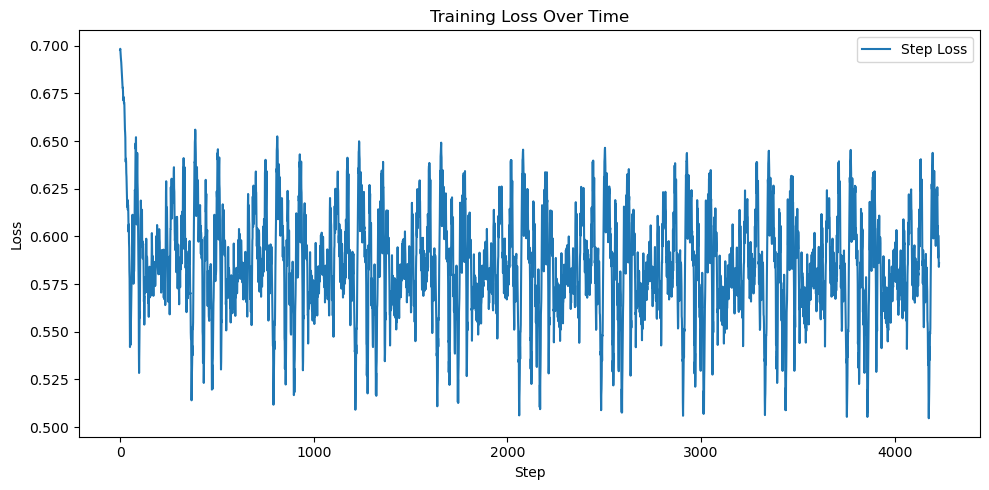

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(avg10_loss, label="Step Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Over Time")
plt.legend()

plt.tight_layout()
plt.show()